# DandeLiion API - Example Notebook

In [1]:
import os

import dandeliion.client as dandeliion
import numpy as np
import matplotlib.pyplot as plt

# Optional
import pybamm

# The following lines enable logging output in this notebook
import sys
import logging

logging.basicConfig(stream=sys.stdout, level=logging.INFO)

In [2]:
print("DadneLiion Client version:", dandeliion.__version__)

DadneLiion Client version: 2.0.0


### Authentication
Define the simulator object by providing the API URL and API token:

In [ ]:
api_url = "https://api.dandeliion.com"
api_key = os.environ["DANDELIION_API_KEY"]
simulator = dandeliion.Simulator(api_url, api_key)

### Battery parameters
Can be a valid BPX file name/path or already read-in valid BPX as a `dict` or `BPX` object itself:

In [4]:
params = "BPX/AE_gen1_BPX.json"

### Experiment
PyBaMM or DandeLiion `Experiment` object, for example:

In [5]:
# Drive cycle data
import pandas as pd

drive_cycle_data = pd.read_csv("drive_cycles/US06.csv", comment="#", header=None).to_numpy()
drive_cycle = np.column_stack([drive_cycle_data[:, 0], -drive_cycle_data[:, 1]])  # Negative current for discharge

# Use dandeliion.Experiment if PyBaMM is not installed
# experiment = dandeliion.Experiment(
experiment = pybamm.Experiment(
    [
        (
            "Discharge at 1C until 3.8 V",
            "Hold at 3.8 V for 10 minutes (5 second period)",
            "Rest for 300 seconds",
            "Charge at 2000 mA for 1 hour or until 4.0 V",
            "Rest for 5 min",
            "Discharge at 20W for 20 minutes or until 2.5V",
            "Rest for 300 s (1 second period)",
            "Charge at C/2 until 3.8 V (0.5 min period)",
            "Hold at 3.8V for 0.1 hr (1s period)",
        ),
        (pybamm.step.current(drive_cycle),) * 2,
    ],
    period="10 s",
)

### Additional model/backend-specific parameters
Define a dictionary of extra parameters outside the BPX standard, such as mesh, initial state of charge or voltage, etc.:

In [6]:
extra_params = {}

# Number of mesh points in PyBaMM format (default is 16 mesh points everywhere):
extra_params["Mesh"] = {"x_n": 16, "x_s": 16, "x_p": 16, "r_n": 16, "r_p": 16}

# Initial state of charge (default is 1):
extra_params["Initial SOC"] = 1.0

# Lumped thermal model (comment out for isothermal model)
extra_params["Lumped thermal model"] = 1.0

extra_params["Heat transfer coefficient [W.m-2.K-1]"] = 10.0

# Set extra_resources to True if runtime is estimated to exceed 15 mins or memory required exceeds 3 GB (Default is False)
extra_params["extra_resources"] = False

### Start the simulation in the cloud

In [7]:
solution = dandeliion.solve(
    simulator=simulator,
    params=params,
    experiment=experiment,  # optional (1C discharge for 1 hour or until the `Lower voltage cut-off [V]` from BPX will be used by default)
    extra_params=extra_params,  # optional (initial conditions from the BPX, fully charged state, and single cell Newman model with constant temperature will be used by default)
    is_blocking=False,  # optional (`True` by default)
)

/Users/ivan/workspace/dandeliion-client/.venv-test/lib/python3.13/site-packages/pydantic/_internal/_decorators_v1.py:171: UserWarning: The minimum voltage computed from the STO limits (2.4988861558265327 V) is less than the lower voltage cut-off (2.5 V) with the absolute tolerance v_tol = 0.001 V
  model_dict_new = validator(model_dict)


If solve is run in non-blocking mode, you can still force the program to wait for the simulation to finish by calling `join()` on the solution returned by it (when used for an already finished simulation, it simply returns instantly).

In [8]:
print("Status:", solution.status)
solution.join()
print("Status:", solution.status)

Status: succeeded
Status: succeeded


### Accessing the log file 

In [9]:
print(solution.log)

Your simulation is now running on AWS Lambda. 
[2026-08-17 10:58:41.711] [info] Starting dandeliion-models v0.3.6...
[2026-08-17 10:58:41.711] [info] Parsing input JSON file parameters.json...
[2026-08-17 10:58:41.716] [info] Input JSON file parsing time: 5.519 ms
[2026-08-17 10:58:41.716] [info] Initialising simulation parameters...
[2026-08-17 10:58:41.716] [info] BPX Title: About:Energy Gen1 Demo 21700 NMC811|graphite 5 Ah cell
[2026-08-17 10:58:41.716] [info] BPX Model: DFN
[2026-08-17 10:58:41.723] [info] Thermal model: Lumped
[2026-08-17 10:58:41.723] [info] Found time series input...
[2026-08-17 10:58:41.723] [info] Time series input: Current [A]
[2026-08-17 10:58:41.723] [info] Found DandeLiion Experiment...
[2026-08-17 10:58:41.723] [info] Number of instructions to parse: 11
[2026-08-17 10:58:41.723] [info] Solver mode: Fast (default)
[2026-08-17 10:58:41.723] [info] Simulation parameters initialisation time: 6.987 ms
[2026-08-17 10:58:41.723] [info] Starting the simulation...

### Results
Print all available keys in the solution object.
Here method `keys()` is used to get all available keys in the solution object.

In [10]:
for key in sorted(solution.keys()):
    print(key)

Charge [A.h]
Current [A]
Electrolyte concentration [mol.m-3]
Electrolyte potential [V]
Electrolyte x-coordinate [m]
Temperature [K]
Time [s]
Voltage [V]
X-averaged negative electrode exchange current density [A.m-2]
X-averaged negative electrode potential [V]
X-averaged negative electrode surface concentration [mol.m-3]
X-averaged positive electrode exchange current density [A.m-2]
X-averaged positive electrode potential [V]
X-averaged positive electrode surface concentration [mol.m-3]


In [11]:
# Print the final values of time, voltage, and temperature
print(f"Final time [s]: {solution['Time [s]'][-1]}")
print(f"Final voltage [V]: {solution['Voltage [V]'][-1]}")
print(f"Final temperature [K]: {solution['Temperature [K]'][-1]}")

Final time [s]: 6842.7109375
Final voltage [V]: 3.686065930383756
Final temperature [K]: 299.6683589251223


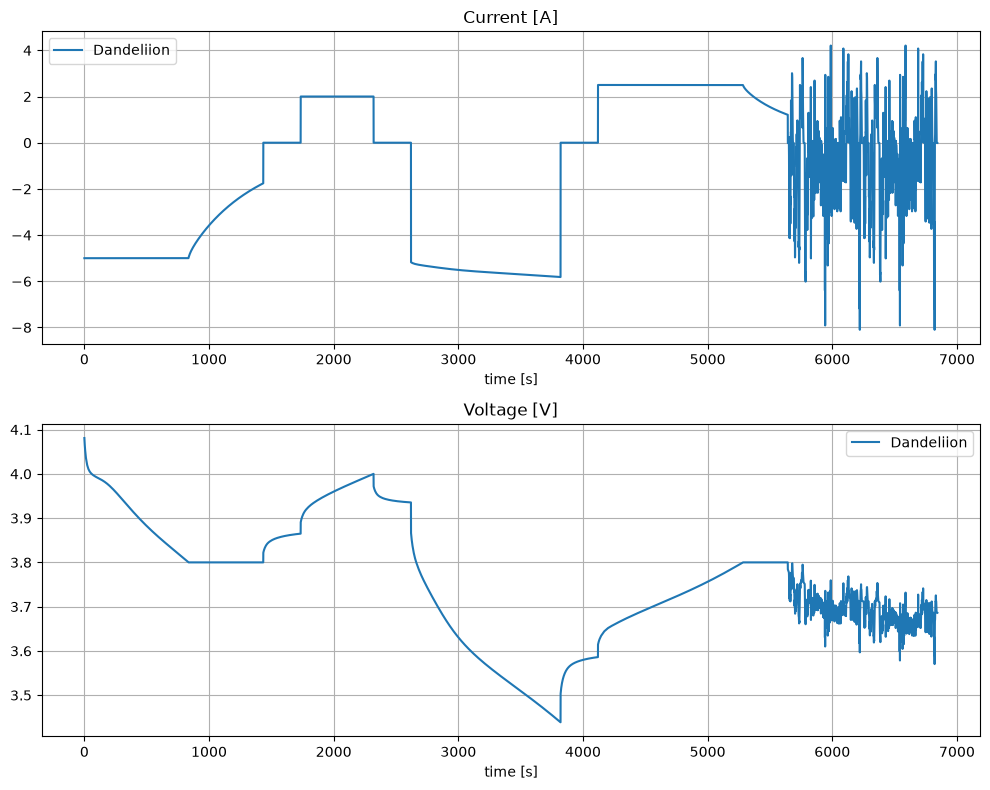

In [12]:
# Plot current and voltage vs time.
# Here we access scalar values vs time.
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(solution["Time [s]"], solution["Current [A]"], label="Dandeliion")
axs[0].set_xlabel("time [s]")
axs[0].set_title("Current [A]")
axs[0].legend()
axs[0].grid()
axs[1].plot(solution["Time [s]"], solution["Voltage [V]"], label="Dandeliion")
axs[1].set_xlabel("time [s]")
axs[1].set_title("Voltage [V]")
axs[1].legend()
axs[1].grid()
plt.tight_layout()
plt.show()

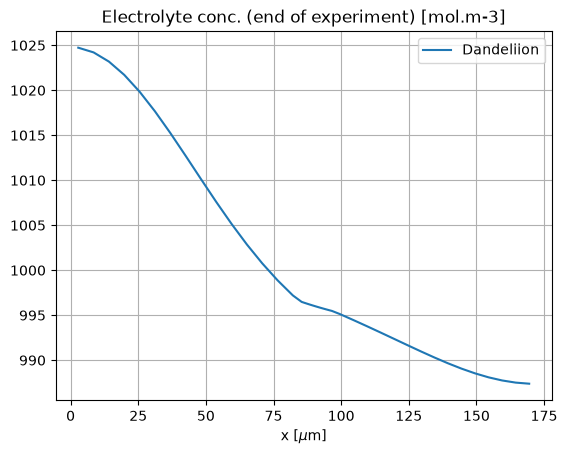

In [13]:
# Concentration in the electrolyte vs `x` at the last time step.
# Here we access spatially dependent values vs time.
plt.plot(
    solution["Electrolyte x-coordinate [m]"] * 1e6,
    solution["Electrolyte concentration [mol.m-3]"][-1],
    label="Dandeliion",
)
plt.xlabel(r"x [$\mu$m]")
plt.title("Electrolyte conc. (end of experiment) [mol.m-3]")
plt.legend()
plt.grid()
plt.show()

In [14]:
# A list of output times (optional)
t_eval = np.arange(0, 20, 1)

# If the user needs the solution at the `t_eval` times, the following code can be used (works only correctly on columns with timeline data).
# This is a linear interpolation with constant extrapolation:
print("Time [s]\tVoltage [V]")
for t, voltage in zip(t_eval, solution["Voltage [V]"](t=t_eval)):
    print(f"{t}\t{voltage}")

Time [s]	Voltage [V]
0	4.080929637972612
1	4.075595482007967
2	4.070699354141942
3	4.066037214129987
4	4.062102224199777
5	4.058248028723095
6	4.0543938332464124
7	4.051336119170483
8	4.048619754266307
9	4.045903389362129
10	4.043187024457953
11	4.040470659553775
12	4.037754294649599
13	4.035368866804824
14	4.03375562543199
15	4.032142384059156
16	4.030529142686323
17	4.028915901313488
18	4.027302659940655
19	4.025689418567821


### Storing and retrieving simulation and its solutions

You can export simulation metadata and logs at any time. Successful results are streamed into the bundle. Completed bundles restore offline. To reconnect an incomplete bundle, explicitly provide both `api_url` and `api_key`; the bundle never chooses where a token is sent.

In [15]:
solution_file = "test_solution.json"

solution.dump(solution_file)
restored_solution = dandeliion.Simulator.restore(solution_file)

In [16]:
# Print the final values of time, voltage, and temperature
print(f"Final time [s]: {restored_solution['Time [s]'][-1]}")
print(f"Final voltage [V]: {restored_solution['Voltage [V]'][-1]}")
print(f"Final temperature [K]: {restored_solution['Temperature [K]'][-1]}")

Final time [s]: 6842.7109375
Final voltage [V]: 3.686065930383756
Final temperature [K]: 299.6683589251223
